t‑SNE: нелинейное вложение, оптимизирует дивергенцию Кульбака–Лейблера между распределениями близостей точек, хорошо показывает локальные кластеры, но медленно, плохо сохраняет глобальные расстояния, чувствительно к perplexity и random_state.

UMAP: основан на теории многобразий и топологии, строит взвешенный граф соседей и оптимизирует кросс‑энтропию; быстрее t‑SNE, лучше сохраняет глобальную структуру, более устойчив к малым изменениям параметров (n_neighbors, min_dist).

TriMAP: ориентирован на сохранение глобальной структуры через тройки точек (anchor, сосед, далёкий), улучшает глобальное расположение кластеров при сохранении локальной структуры.

PaCMAP: управляет соотношением близких, средних и далёких пар, чтобы одновременно хорошо держать локальные кластеры и общую форму; показывает хорошие результаты на омикс‑данных и эмбеддингах.

PHATE: использует диффузионные процессы и потенциал для визуализации непрерывных траекторий (например, дифференцировка клеток), хорошо показывает как кластеры, так и переходы между ними.



In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import pairwise_distances

from sklearn.manifold import TSNE

import umap
import trimap
import pacmap
import phate


In [37]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print("Iris:", X_iris.shape, len(np.unique(y_iris)))


Iris: (150, 4) 3


In [38]:
path = "online_shoppers_intention.csv"
df = pd.read_csv(path)

# кодирование категориальных признаков
df = pd.get_dummies(df, drop_first=True)

feature_cols = [c for c in df.columns if c != "Revenue"]
X_own = df[feature_cols].values
y_own = df["Revenue"].astype(int).values

print("Shoppers:", X_own.shape, len(np.unique(y_own)))

Shoppers: (12330, 26) 2


In [39]:
# Проверка уникальных классов
print(np.unique(y_iris), np.unique(y_own))

[0 1 2] [0 1]


In [40]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)
scaler_own = StandardScaler()
X_own_scaled = scaler_own.fit_transform(X_own)

Функции для DR и оценки разделения

In [41]:
def run_tsne(X, random_state=42, perplexity=30, learning_rate=200, max_iter=1000):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        random_state=random_state
    )
    return tsne.fit_transform(X)


def run_umap(X, random_state=42, n_neighbors=15, min_dist=0.1):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state
    )
    return reducer.fit_transform(X)


def run_trimap(X, random_state=42, n_inliers=10, n_outliers=5):
    reducer = trimap.TRIMAP(
        n_dims=2,
        n_inliers=n_inliers,
        n_outliers=n_outliers
    )
    return reducer.fit_transform(X)


def run_pacmap(X, random_state=42, n_neighbors=10):
    reducer = pacmap.PaCMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        random_state=random_state
    )
    return reducer.fit_transform(X)


def run_phate(X, random_state=42, knn=15):
    phate_op = phate.PHATE(
        n_components=2,
        knn=knn,
        random_state=random_state
    )
    return phate_op.fit_transform(X)


Функция оценки качества разделения

In [42]:
def separation_score(X_2d, y):
    D = pairwise_distances(X_2d)
    same = D[y[:, None] == y[None, :]]
    diff = D[y[:, None] != y[None, :]]
    return same.mean(), diff.mean(), diff.mean() / same.mean()

In [43]:
def plot_embedding(X_2d, y, title):
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        x=X_2d[:,0],
        y=X_2d[:,1],
        hue=y,
        palette="tab10",
        s=30,
        legend="full"
    )
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend(title="Класс", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout()
    plt.show()

c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculating PHATE...
  Running PHATE on 150 observations and 4 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculating affinities...
    Calculated affinities in 0.01 seconds.
  Calculated graph and diffusion operator in 0.02 seconds.
  Calculating optimal t...
    Automatically selected t = 22
  Calculated optimal t in 0.02 seconds.
  Calculating diffusion potential...
  Calculating metric MDS...


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\graphtools\graphs.py:803: RuntimeWarning: Detected zero distance between samples 101 and 142. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 0.15 seconds.
Calculated PHATE in 0.19 seconds.


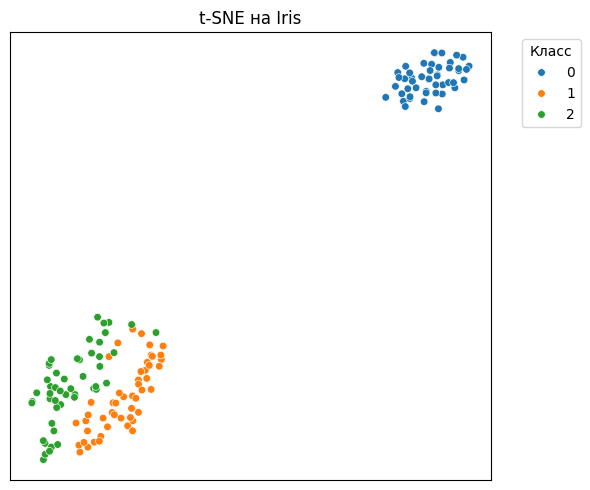

t-SNE: внутрикласс.=3.580, межкласс.=28.091, ratio=7.846


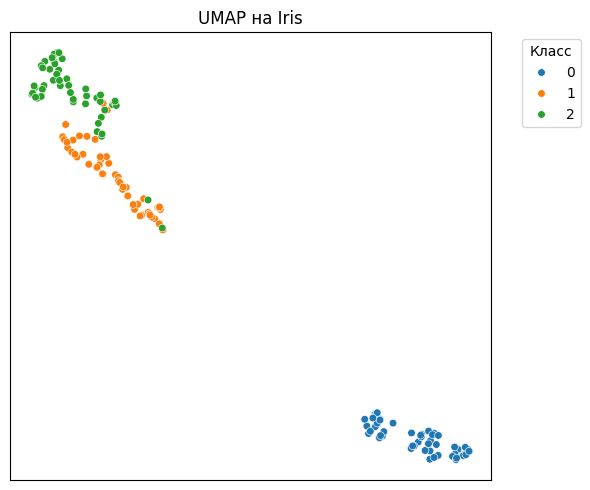

UMAP: внутрикласс.=1.980, межкласс.=13.003, ratio=6.567


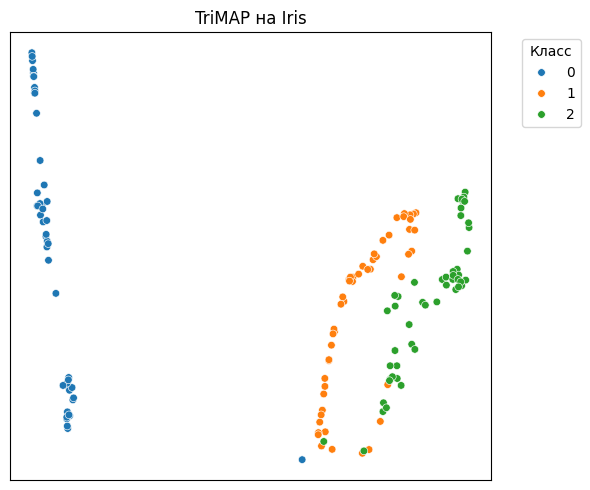

TriMAP: внутрикласс.=11.136, межкласс.=60.324, ratio=5.417


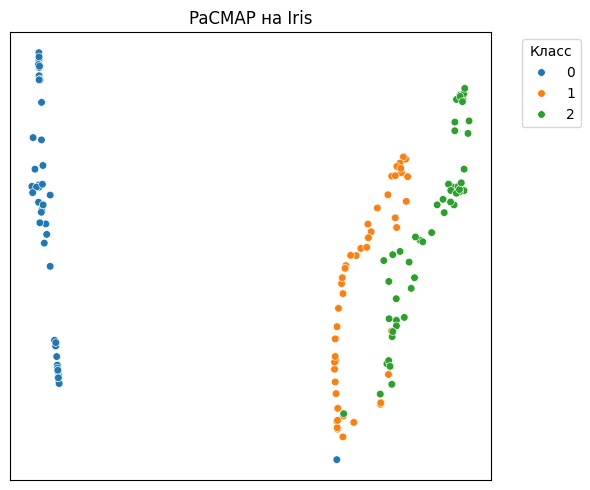

PaCMAP: внутрикласс.=3.470, межкласс.=17.674, ratio=5.093


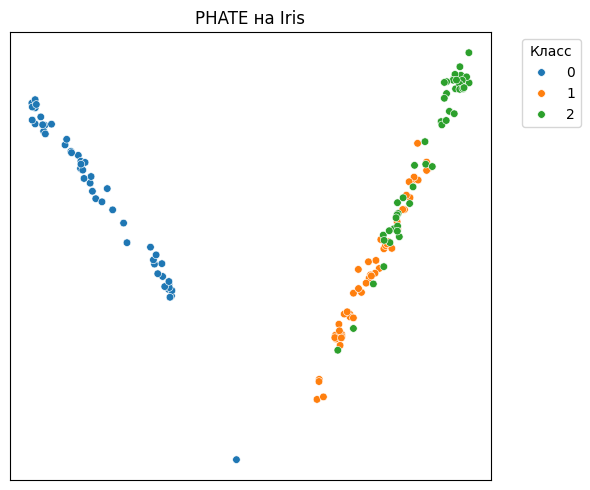

PHATE: внутрикласс.=0.026, межкласс.=0.121, ratio=4.610


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculating PHATE...
  Running PHATE on 12330 observations and 26 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.23 seconds.
    Calculating affinities...


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\graphtools\graphs.py:810: RuntimeWarning: Detected zero distance between 223 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated affinities in 0.42 seconds.
  Calculated graph and diffusion operator in 0.68 seconds.
  Calculating landmark operator...
    Calculating SVD...


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\phate\phate.py:919: RuntimeWarning: Graph is disconnected with 2 connected components. This may indicate that your knn parameter (currently 15) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


    Calculated SVD in 1.14 seconds.
    Calculating KMeans...
    Calculated KMeans in 7.62 seconds.
  Calculated landmark operator in 8.75 seconds.
  Calculating optimal t...
    Automatically selected t = 40
  Calculated optimal t in 3.53 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.80 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.65 seconds.
Calculated PHATE in 17.04 seconds.


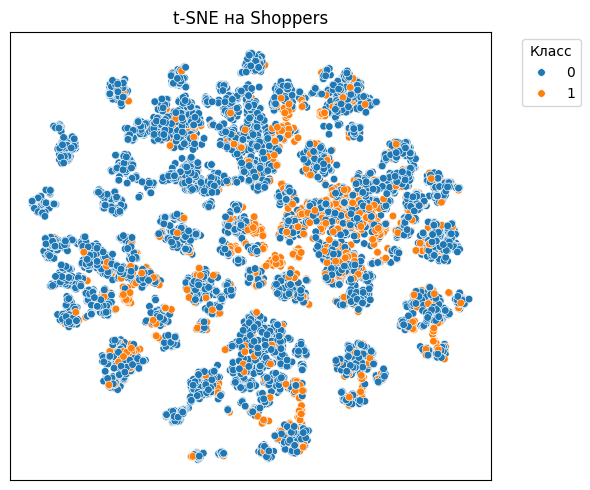

t-SNE: внутрикласс.=78.529, межкласс.=75.119, ratio=0.957


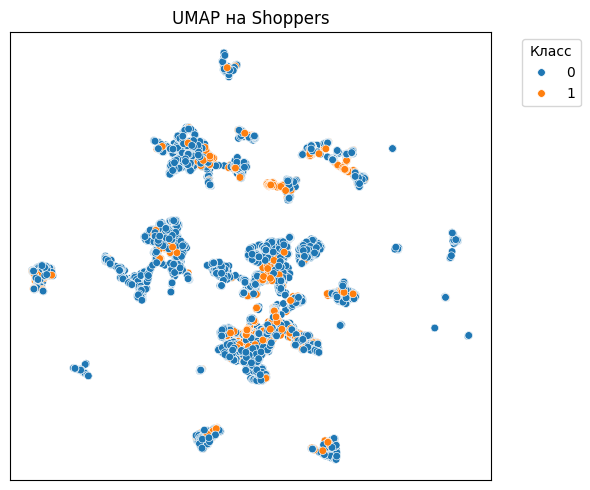

UMAP: внутрикласс.=10.665, межкласс.=10.617, ratio=0.995


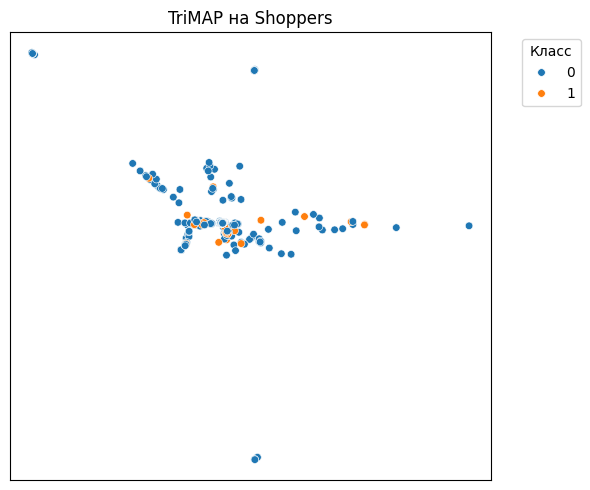

TriMAP: внутрикласс.=304.556, межкласс.=211.518, ratio=0.695


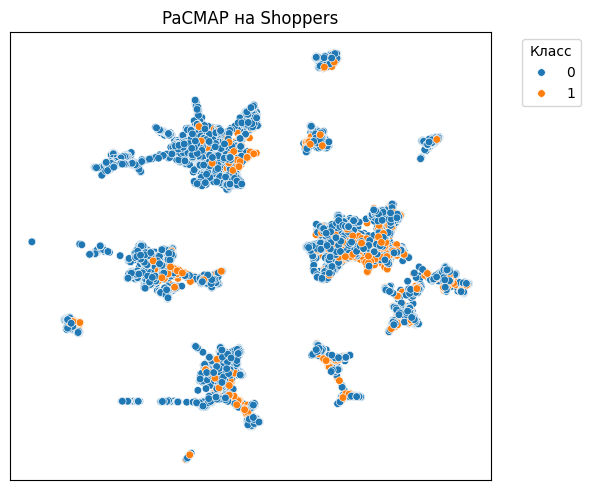

PaCMAP: внутрикласс.=20.042, межкласс.=19.868, ratio=0.991


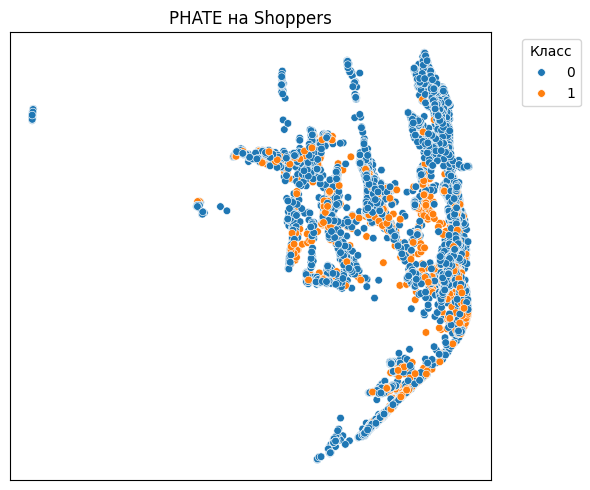

PHATE: внутрикласс.=0.025, межкласс.=0.023, ratio=0.919


In [44]:
X_list = []
names = []

X_tsne_iris = run_tsne(X_iris_scaled)
X_list.append(X_tsne_iris); names.append("t-SNE")

X_umap_iris = run_umap(X_iris_scaled)
X_list.append(X_umap_iris); names.append("UMAP")

X_trimap_iris = run_trimap(X_iris_scaled)
X_list.append(X_trimap_iris); names.append("TriMAP")

X_pacmap_iris = run_pacmap(X_iris_scaled)
X_list.append(X_pacmap_iris); names.append("PaCMAP")

X_phate_iris = run_phate(X_iris_scaled)
X_list.append(X_phate_iris); names.append("PHATE")

for X_emb, name in zip(X_list, names):
    plot_embedding(X_emb, y_iris, f"{name} на Iris")
    same, diff, ratio = separation_score(X_emb, y_iris)
    print(f"{name}: внутрикласс.={same:.3f}, межкласс.={diff:.3f}, ratio={ratio:.3f}")

X_list = []
names = []

X_tsne_own = run_tsne(X_own_scaled)
X_list.append(X_tsne_own); names.append("t-SNE")

X_umap_own = run_umap(X_own_scaled)
X_list.append(X_umap_own); names.append("UMAP")

X_trimap_own = run_trimap(X_own_scaled)
X_list.append(X_trimap_own); names.append("TriMAP")

X_pacmap_own = run_pacmap(X_own_scaled)
X_list.append(X_pacmap_own); names.append("PaCMAP")

X_phate_own = run_phate(X_own_scaled)
X_list.append(X_phate_own); names.append("PHATE")

for X_emb, name in zip(X_list, names):
    plot_embedding(X_emb, y_own, f"{name} на Shoppers")
    same, diff, ratio = separation_score(X_emb, y_own)
    print(f"{name}: внутрикласс.={same:.3f}, межкласс.={diff:.3f}, ratio={ratio:.3f}")

Сравнение устойчивости

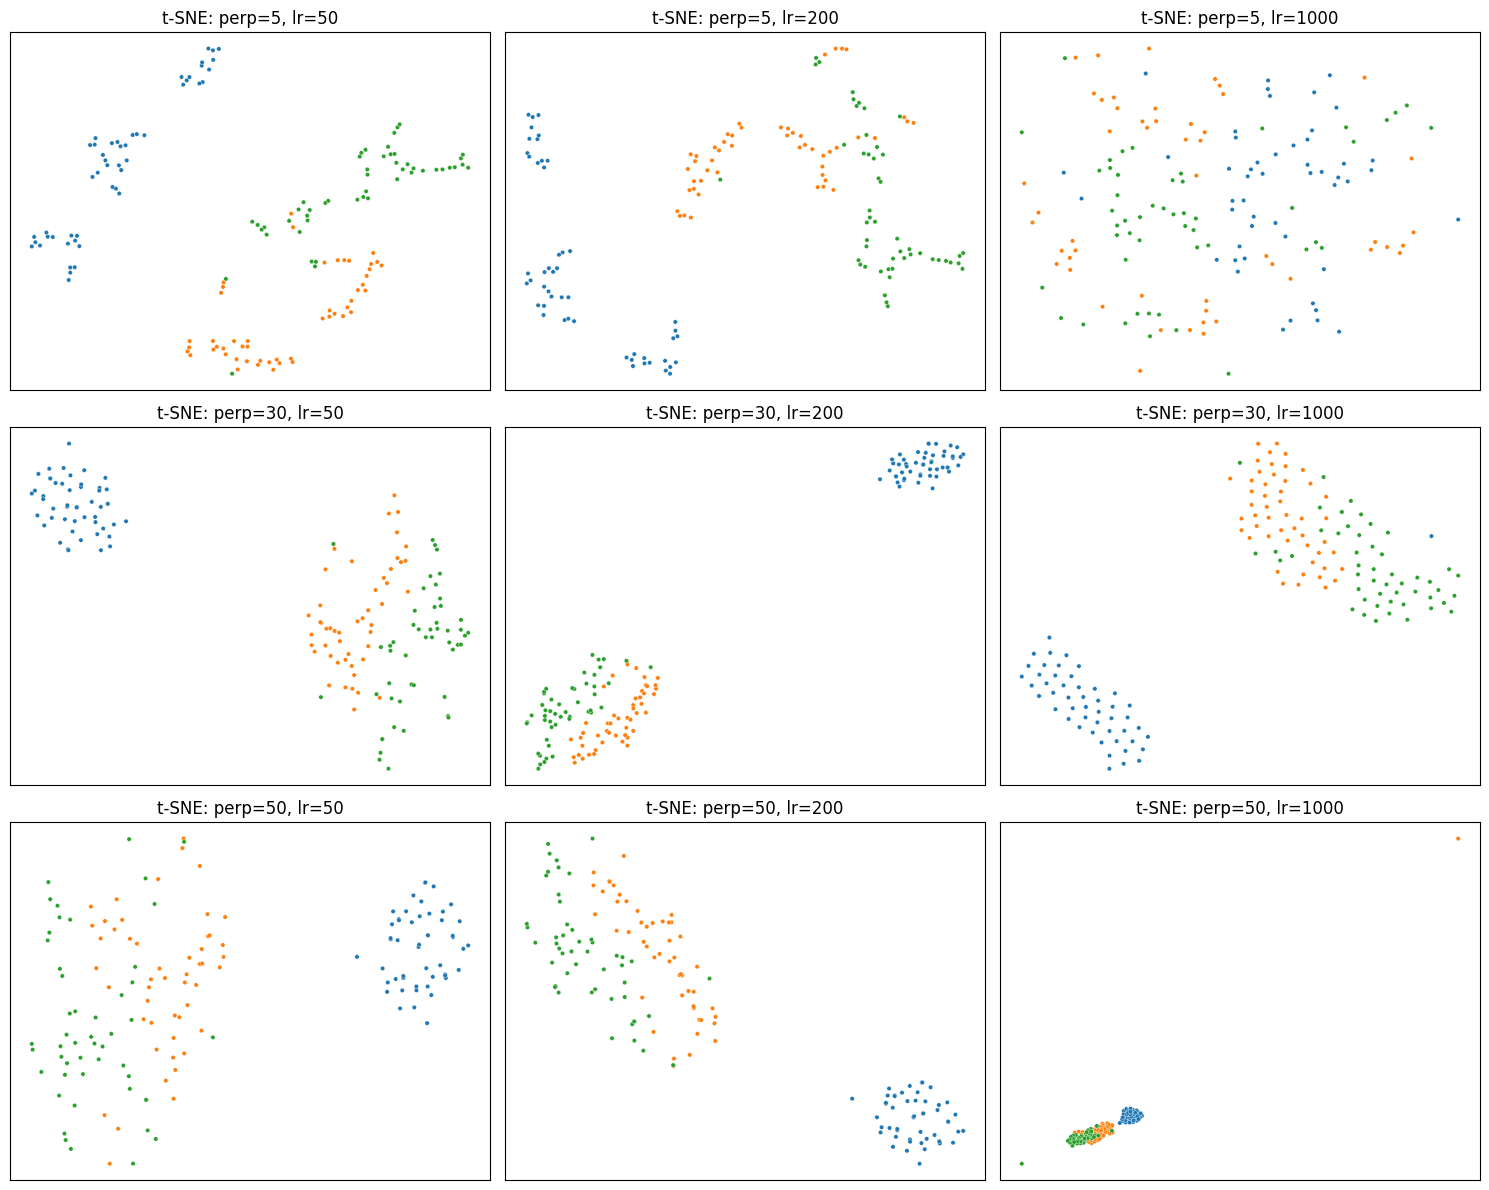

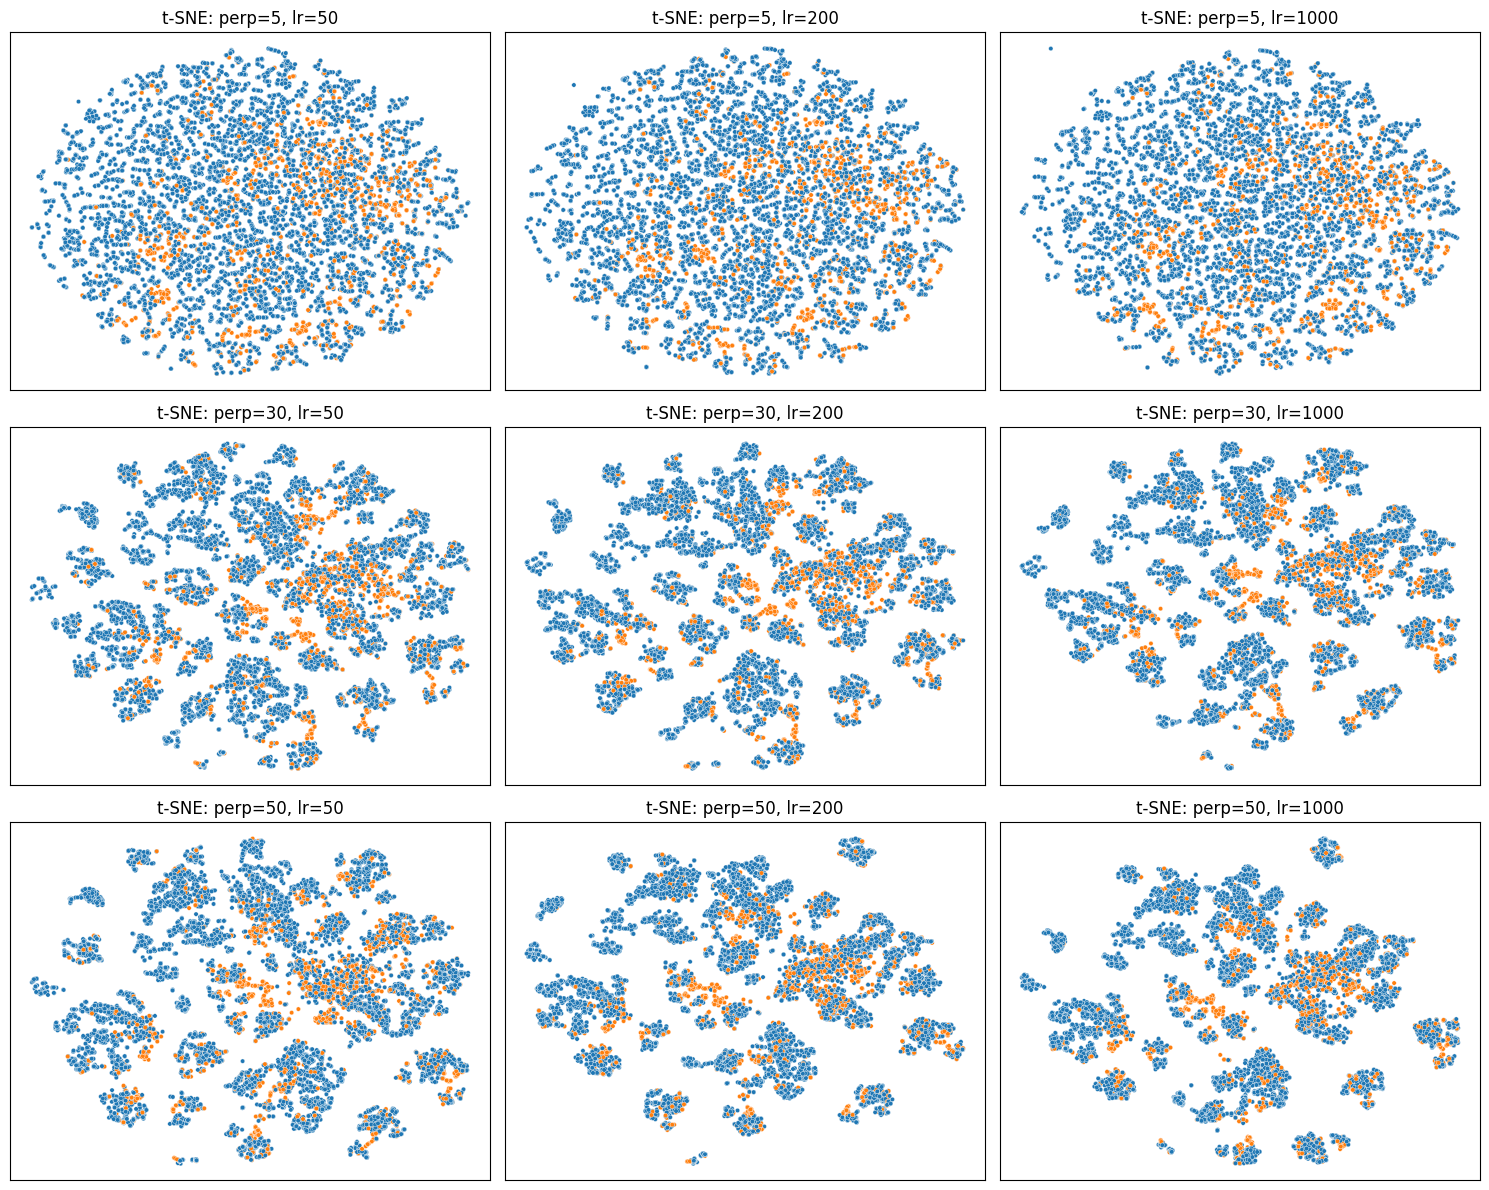

In [45]:
perplexities = [5, 30, 50]
lrs = [50, 200, 1000]

fig, axes = plt.subplots(len(perplexities), len(lrs), figsize=(15,12))
for i, perp in enumerate(perplexities):
    for j, lr in enumerate(lrs):
        X_emb = run_tsne(X_iris_scaled, perplexity=perp, learning_rate=lr)
        ax = axes[i,j]
        sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=y_iris, palette="tab10", s=10, ax=ax, legend=False)
        ax.set_title(f"t-SNE: perp={perp}, lr={lr}")
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(perplexities), len(lrs), figsize=(15,12))
for i, perp in enumerate(perplexities):
    for j, lr in enumerate(lrs):
        X_emb = run_tsne(X_own_scaled, perplexity=perp, learning_rate=lr)
        ax = axes[i,j]
        sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=y_own, palette="tab10", s=10, ax=ax, legend=False)
        ax.set_title(f"t-SNE: perp={perp}, lr={lr}")
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

Нужно описать, как меняется форма и расположение кластеров при разных perplexity и learning_rate и что визуализация t‑SNE может сильно меняться.

|При малой perplexity (5) формируются маленькие локальные кластеры.

При 30 структура становится более глобальной.

При 50 расстояния между кластерами увеличиваются. Также изменение learning_rate может приводить к различным формам кластеров.
Это показывает, что визуализация t-SNE может значительно меняться при разных гиперпараметрах.|

Обычно структура UMAP меняется плавнее, кластеры остаются узнаваемыми при разумном диапазоне параметров.

*Задача* Аналогично нужно сделать по одной строке графиков для TriMAP, PaCMAP, PHATE с варьированием ключевого параметра (количество соседей или похожий гиперпараметр) и показать, насколько устойчив рисунок.



| Метод  | Скорость на больших данных                   | Локальное разделение              | Глобальная структура                            | Чувствительность к параметрам                         | Комментарий                                        |
| ------ | -------------------------------------------- | --------------------------------- | ----------------------------------------------- | ----------------------------------------------------- | -------------------------------------------------- |
| t‑SNE  | Низкая l                    | Отличное                   | Слабая                                   | Высокая (perplexity, lr, random_state) aicompetence+2 | Хорошо для локальных кластеров, тяжёлый тюнинг     |
| UMAP   | Высокая l                   | Очень хорошее   | Лучшая, чем у t‑SNE           | Ниже, чем у t‑SNE aicompetence+2                      | Хороший баланс локал/глобал, удобен в практике     |
| TriMAP | Средняя                              | Хорошее                   | Сильный упор на глобальную структуру    | Умеренная                                     | Лучше показывает относительное положение кластеров |
| PaCMAP | Средняя                               | Отличное                   | Хорошее                                  | Умеренная                                      | Часто даёт чёткие кластеры и форму многобразия     |
| PHATE  | Средняя/низкая (зависит от размера)   | Хорошее        | Очень хорошее, особенно для траекторий   | Умеренная                          | Сильный метод для непрерывных переходов            |

Calculating PHATE...
  Running PHATE on 12330 observations and 26 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.20 seconds.
    Calculating affinities...


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\graphtools\graphs.py:810: RuntimeWarning: Detected zero distance between 223 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(
c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\graphtools\graphs.py:505: RuntimeWarning: divide by zero encountered in divide
  scaled = distances_i / bw
c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\graphtools\graphs.py:505: RuntimeWarning: invalid value encountered in divide
  scaled = distances_i / bw
c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\graphtools\graphs.py:540: RuntimeWarning: invalid value encountered in divide
  scaled = distances_i / bw


    Calculated affinities in 0.35 seconds.
  Calculated graph and diffusion operator in 0.57 seconds.
  Calculating landmark operator...
    Calculating SVD...


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\phate\phate.py:919: RuntimeWarning: Graph is disconnected with 4 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


    Calculated SVD in 0.88 seconds.
    Calculating KMeans...
    Calculated KMeans in 6.50 seconds.
  Calculated landmark operator in 7.38 seconds.
  Calculating optimal t...
    Automatically selected t = 55
  Calculated optimal t in 4.19 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 1.18 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.64 seconds.
Calculated PHATE in 16.59 seconds.
Calculating PHATE...
  Running PHATE on 12330 observations and 26 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.20 seconds.
    Calculating affinities...


...

    Calculated SVD in 1.08 seconds.
    Calculating KMeans...
    Calculated KMeans in 4.42 seconds.
  Calculated landmark operator in 5.50 seconds.
  Calculating optimal t...
    Automatically selected t = 33
  Calculated optimal t in 3.60 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.73 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.63 seconds.
Calculated PHATE in 13.70 seconds.
Calculating PHATE...
  Running PHATE on 12330 observations and 26 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.22 seconds.
    Calculating affinities...


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\graphtools\graphs.py:810: RuntimeWarning: Detected zero distance between 223 pairs of samples. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    Calculated affinities in 0.41 seconds.
  Calculated graph and diffusion operator in 0.66 seconds.
  Calculating landmark operator...
    Calculating SVD...


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\phate\phate.py:919: RuntimeWarning: Graph is disconnected with 2 connected components. This may indicate that your knn parameter (currently 20) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


    Calculated SVD in 1.22 seconds.
    Calculating KMeans...
    Calculated KMeans in 5.27 seconds.
  Calculated landmark operator in 6.50 seconds.
  Calculating optimal t...
    Automatically selected t = 40
  Calculated optimal t in 3.52 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.77 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by -1.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 2.64 seconds.
Calculated PHATE in 14.72 seconds.


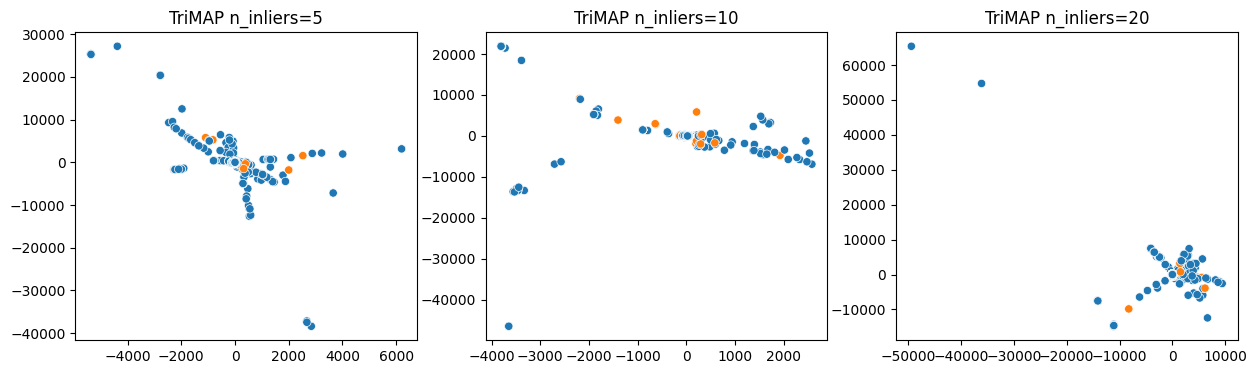

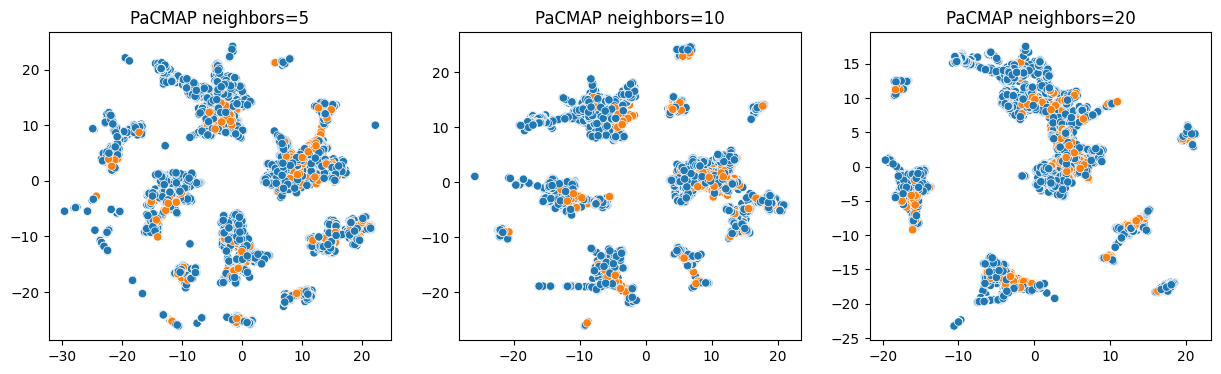

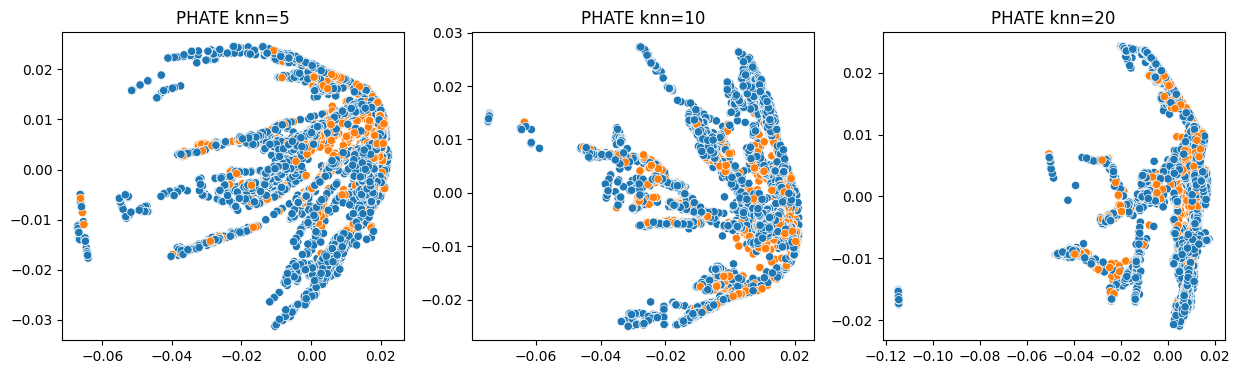

In [46]:
neighbors = [5,10,20]

# TriMAP
fig, axes = plt.subplots(1,3, figsize=(15,4))
for i,n in enumerate(neighbors):
    X_emb = run_trimap(X_own_scaled, n_inliers=n)
    sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=y_own, palette="tab10", ax=axes[i], legend=False)
    axes[i].set_title(f"TriMAP n_inliers={n}")

# PaCMAP
fig, axes = plt.subplots(1,3, figsize=(15,4))
for i,n in enumerate(neighbors):
    X_emb = run_pacmap(X_own_scaled, n_neighbors=n)
    sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=y_own, palette="tab10", ax=axes[i], legend=False)
    axes[i].set_title(f"PaCMAP neighbors={n}")

# PHATE
fig, axes = plt.subplots(1,3, figsize=(15,4))
for i,n in enumerate(neighbors):
    X_emb = run_phate(X_own_scaled, knn=n)
    sns.scatterplot(x=X_emb[:,0], y=X_emb[:,1], hue=y_own, palette="tab10", ax=axes[i], legend=False)
    axes[i].set_title(f"PHATE knn={n}")

# Варианты препроцессинга
*Задача* — явно сравнить, как UMAP и t‑SNE реагируют на разные варианты нормировки и отбора признаков.

## Определяем три сценария
Без масштабирования (сырой набор признаков).

StandardScaler (z‑нормировка).

MinMaxScaler + отбор признаков по дисперсии (эмуляция feature selection).

Задание. Проделать все три сценария. Обучить все модели при разных сценария кластеризации. 
Нужно в результате:
1. описать, какие признаки были отброшены и почему это может влиять на качество кластеризации во вложенном пространстве.
1. сравнить вычислительное время и сделать вывод о масштабируемости методов
1. изменить гиперпараметры (perplexity, n_neighbors, min_dist) и исследовать совместное влияние гиперпараметров и препроцессинга на структуру кластеров.


In [47]:
# 1. RAW
X_raw = X_own

# 2. StandardScaler
scaler = StandardScaler()
X_std = scaler.fit_transform(X_own)

# 3. MinMax + FeatureSelection
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_own)

selector = VarianceThreshold(threshold=0.01)
X_fs = selector.fit_transform(X_scaled)

selected_features = np.array(feature_cols)[selector.get_support()]
print("Выбранные признаки:", selected_features)
for name, X in [
    ("RAW", X_raw),
    ("StandardScaler", X_std),
    ("MinMax+FeatureSelection", X_fs)
]:
    start = time.time()
    emb = run_umap(X)
    end = time.time()
    print(name, "time:", end-start)

Выбранные признаки: ['Administrative' 'BounceRates' 'ExitRates' 'SpecialDay'
 'OperatingSystems' 'Browser' 'Region' 'TrafficType' 'Weekend' 'Month_Dec'
 'Month_Feb' 'Month_Jul' 'Month_June' 'Month_Mar' 'Month_May' 'Month_Nov'
 'Month_Oct' 'Month_Sep' 'VisitorType_Returning_Visitor']


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


RAW time: 11.91211223602295


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


StandardScaler time: 5.55036735534668


c:\Users\muras\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


MinMax+FeatureSelection time: 6.661581516265869
